# Tutorial 04 — Particle Filters: PPF and PF

This notebook dives deep into the two **particle filter** variants available in `awesomepkf`:

| Filter | Class | Model type | Key parameters |
|--------|-------|------------|----------------|
| PF  | `NonLinear_PF`  | classic or pairwise | `n_particles`, `resample_threshold`, `resample_method` |
| PPF | `NonLinear_PPF` | **pairwise only**   | `n_particles`, `resample_threshold`, `resample_method` |

**What you will learn:**
- Understand the structural difference between the bootstrap PF and the pairwise PPF
- Tune the number of particles and measure the accuracy/cost trade-off
- Compare four resampling strategies: multinomial, systematic, stratified, residual
- Study the impact of the ESS resampling threshold
- Compare PPF and PF against EPKF and UPKF on the same trajectory
- Benchmark computation time vs estimation accuracy

**Prerequisites:** Tutorial 02 — Nonlinear Models

## Setup

In [12]:
import sys, os, time
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from prg import (
    NonLinear_EPKF,
    NonLinear_UPKF,
    NonLinear_PPF,
    NonLinear_PF,
    ParamNonLinear,
    ModelFactoryNonLinear,
    __version__,
)

print(f"awesomepkf version: {__version__}")

SEED            = 42
N               = 500
N_BENCH         = 500
N_REPS          = 3
PARTICLE_COUNTS = [50, 100, 200, 500, 1000]

model_cl = ModelFactoryNonLinear.create("model_x2_y1_classic")
model_pw = ModelFactoryNonLinear.create("model_x2_y1_pairwise")

def make_param(model):
    p  = model.get_params().copy()
    dx = p.pop("dim_x"); dy = p.pop("dim_y")
    return ParamNonLinear(0, dx, dy, **p)

param_cl = make_param(model_cl)
param_pw = make_param(model_pw)
dim_x    = model_cl.get_params()["dim_x"]

def extract(results):
    xu = np.array([r[4].flatten() for r in results if r[4] is not None])
    M  = len(xu)
    xt = np.array([r[1].flatten() for r in results[:M]])
    return xt, xu

def mse(xt, xu):
    return float(np.mean((xt - xu) ** 2))

print(f"Classic  model: {model_cl}")
print(f"Pairwise model: {model_pw}")

awesomepkf version: 0.1.0
Classic  model: Model_x2_y1_classic(dim_x=2, dim_y=1)
Pairwise model: Model_x2_y1_pairwise(dim_x=2, dim_y=1)


---
## 1. Bootstrap PF vs Pairwise PPF

Both filters represent the state distribution as a **weighted set of particles** $\{x_k^{(i)}, w_k^{(i)}\}_{i=1}^{N_p}$ and update weights using likelihood evaluations. They differ in how they **draw proposal particles**:

| | **PF** (Bootstrap) | **PPF** (Pairwise) |
|---|---|---|
| Proposal | Prior: draw $x_{k+1}^{(i)} \sim p(x_{k+1} \mid x_k^{(i)})$ | Pairwise prior: draw $x_{k+1}^{(i)} \sim p(x_{k+1} \mid x_k^{(i)}, y_k)$ |
| Model | Classic **or** pairwise | **Pairwise only** |
| Proposal quality | Standard — ignores latest observation | Improved — observation $y_k$ guides the proposal |
| Internals | Cholesky($Q$) for sampling | Schur complement + Cholesky for joint $(x,y)$ sampling |

Both implement **four resampling strategies** triggered when the **Effective Sample Size (ESS)** falls below a threshold:
$$
\text{ESS} = \frac{1}{\sum_i (w_k^{(i)})^2} < \texttt{resample\_threshold} \times N_p
$$

---
## 2. Impact of the Number of Particles

### 2a. PF on the classic model

In [13]:
print(f"PF — particle count sweep (model_x2_y1_classic, N={N}):")
pf_mse = {}
for np_ in PARTICLE_COUNTS:
    flt = NonLinear_PF(param_cl, n_particles=np_, sKey=SEED)
    res = flt.process_N_data(N=N)
    xt, xu = extract(res)
    pf_mse[np_] = mse(xt, xu)
    print(f"  n_particles={np_:5d}   MSE = {pf_mse[np_]:.6f}")

PF — particle count sweep (model_x2_y1_classic, N=500):
  n_particles=   50   MSE = 0.066390
  n_particles=  100   MSE = 0.054892
  n_particles=  200   MSE = 0.052955
  n_particles=  500   MSE = 0.055898
  n_particles= 1000   MSE = 0.050149


### 2b. PPF on the pairwise model

In [14]:
print(f"PPF — particle count sweep (model_x2_y1_pairwise, N={N}):")
ppf_mse = {}
for np_ in PARTICLE_COUNTS:
    flt = NonLinear_PPF(param_pw, n_particles=np_, sKey=SEED)
    res = flt.process_N_data(N=N)
    xt, xu = extract(res)
    ppf_mse[np_] = mse(xt, xu)
    print(f"  n_particles={np_:5d}   MSE = {ppf_mse[np_]:.6f}")

PPF — particle count sweep (model_x2_y1_pairwise, N=500):
  n_particles=   50   MSE = 0.118855
  n_particles=  100   MSE = 0.119756
  n_particles=  200   MSE = 0.119050
  n_particles=  500   MSE = 0.112906
  n_particles= 1000   MSE = 0.113030


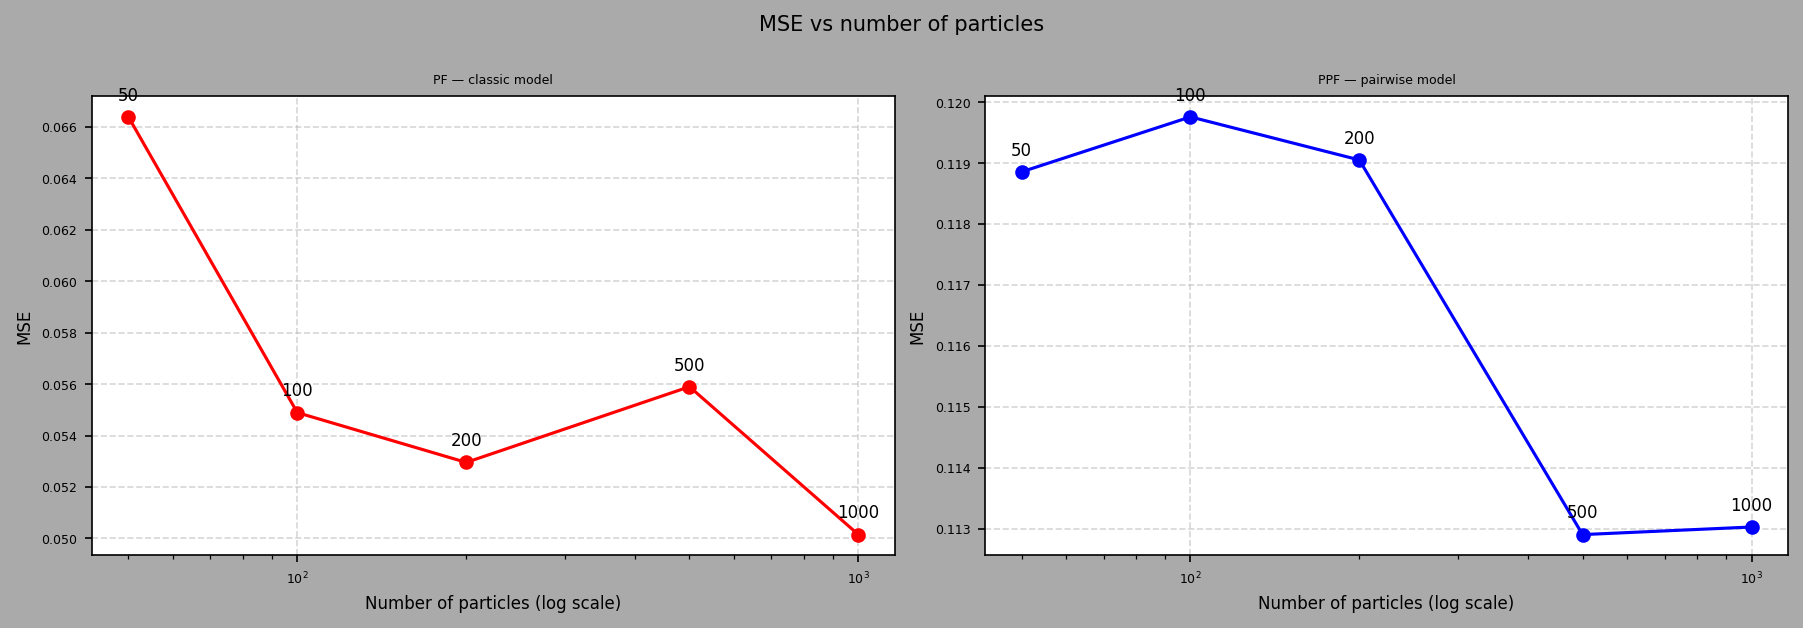

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, label, data, color in zip(
        axes,
        ["PF — classic model", "PPF — pairwise model"],
        [pf_mse, ppf_mse],
        ["C0", "C2"]):
    nps  = list(data.keys())
    mses = list(data.values())
    ax.plot(nps, mses, "o-", color=color, lw=1.5)
    for x_, y_ in zip(nps, mses):
        ax.annotate(str(x_), (x_, y_), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("Number of particles (log scale)")
    ax.set_ylabel("MSE")
    ax.set_title(label)
    ax.grid(True, ls="--", alpha=0.5)

fig.suptitle("MSE vs number of particles", y=1.02)
plt.tight_layout()
plt.show()

The MSE decreases roughly as $O(1/N_p)$ (law of large numbers), but gains saturate beyond a few hundred particles — there is a **diminishing-returns regime** driven by the model's inherent stochasticity.

---
## 3. Resampling Strategies

All four strategies replace a weighted sample by an equally-weighted one of the same size, but differ in how they draw indices:

| Strategy | Description | Variance |
|----------|-------------|----------|
| `multinomial` | Draw $N_p$ i.i.d. indices from $\text{Categorical}(w^{(i)})$ | Highest |
| `systematic` | One uniform draw, then evenly-spaced offsets | Low |
| `stratified` | One uniform draw **per stratum** | Low (default) |
| `residual` | Deterministic floor + multinomial for remainders | Low |

We run the PF with each strategy on the **same simulated trajectory**.

In [16]:
# Simulate a single trajectory on the classic model — reused for all comparisons
ref_sim     = NonLinear_EPKF(param_cl, sKey=SEED)
sim_data_cl = ref_sim.simulate_N_data(N)
print(f"Simulated {len(sim_data_cl)} steps on {model_cl}")

Simulated 501 steps on Model_x2_y1_classic(dim_x=2, dim_y=1)


In [17]:
RESAMPLE_METHODS = ["multinomial", "systematic", "stratified", "residual"]
COLORS_RS        = ["C0", "C1", "C2", "C3"]

print("PF — resampling strategy comparison (same trajectory, n_particles=500):")
rs_results = {}
for method in RESAMPLE_METHODS:
    flt = NonLinear_PF(param_cl, n_particles=500, resample_method=method, sKey=SEED)
    res = flt.process_N_data(N=None, data_generator=iter(sim_data_cl))
    xt, xu = extract(res)
    rs_results[method] = (xt, xu)
    print(f"  [{method:12s}]   MSE = {mse(xt, xu):.6f}")

PF — resampling strategy comparison (same trajectory, n_particles=500):
  [multinomial ]   MSE = 0.052885
  [systematic  ]   MSE = 0.050940
  [stratified  ]   MSE = 0.052028
  [residual    ]   MSE = 0.054044


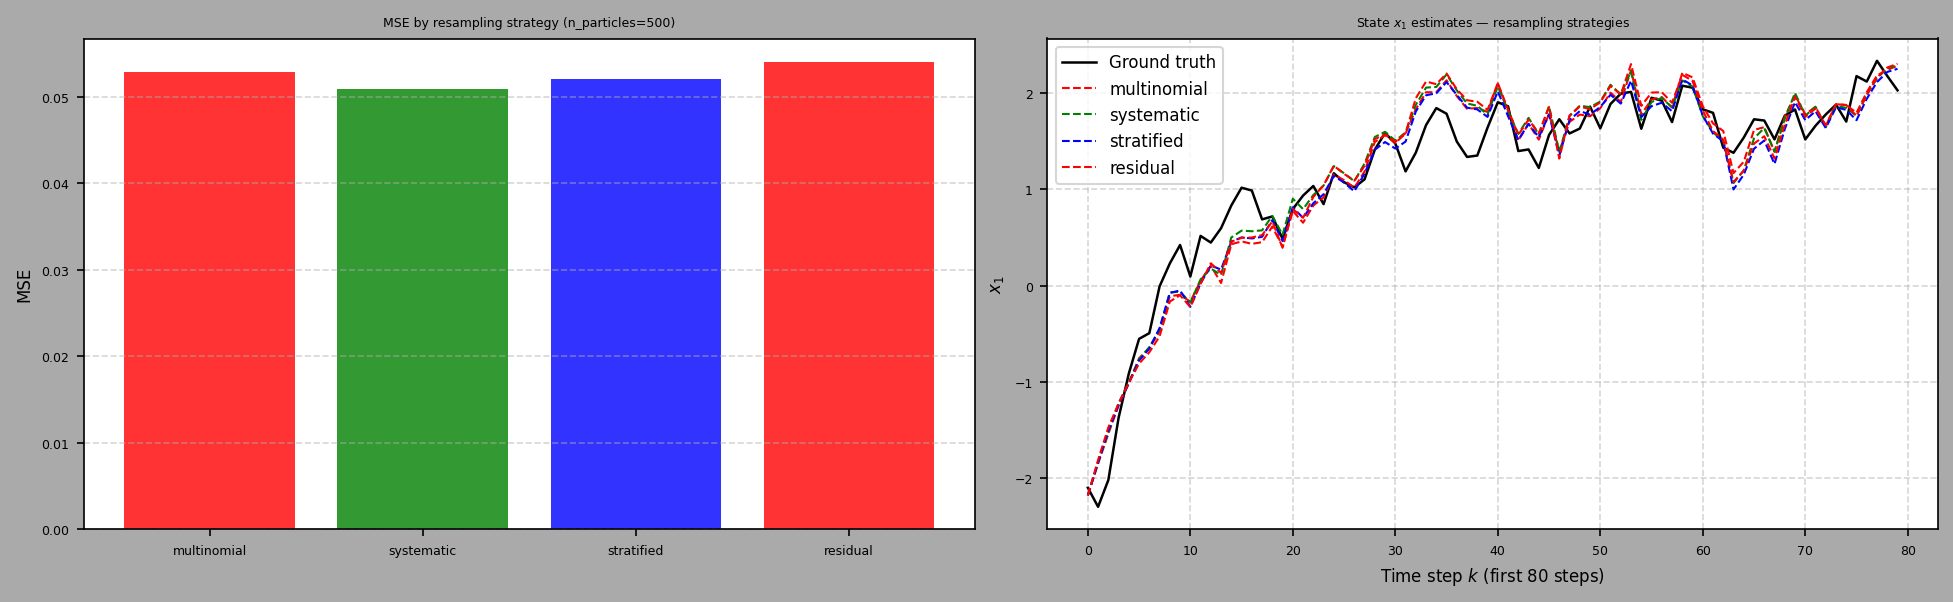

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: MSE bar chart
ax = axes[0]
mse_vals = [mse(*rs_results[m]) for m in RESAMPLE_METHODS]
ax.bar(RESAMPLE_METHODS, mse_vals, color=COLORS_RS, alpha=0.8)
ax.set_ylabel("MSE")
ax.set_title("MSE by resampling strategy (n_particles=500)")
ax.grid(True, axis="y", ls="--", alpha=0.5)

# Right: time series x1 — first 80 steps
ax = axes[1]
WIN = slice(0, 80)
xt_ref = rs_results["stratified"][0]
t = np.arange(len(xt_ref))
ax.plot(t[WIN], xt_ref[WIN, 0], color="black", lw=1.2, label="Ground truth")
for method, color in zip(RESAMPLE_METHODS, COLORS_RS):
    xu = rs_results[method][1]
    ax.plot(t[WIN], xu[WIN, 0], lw=1.0, ls="--", color=color, label=method)
ax.set_xlabel("Time step $k$ (first 80 steps)")
ax.set_ylabel("$x_1$")
ax.set_title("State $x_1$ estimates — resampling strategies")
ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In practice, **stratified** and **systematic** resampling consistently outperform multinomial resampling (lower variance in index selection). The difference is most visible at low particle counts.

---
## 4. ESS Resampling Threshold

The `resample_threshold` parameter controls **how aggressively** resampling is triggered:

- `threshold = 1.0` → resample at **every step** (regardless of ESS)
- `threshold = 0.5` → resample when ESS < 50% of $N_p$ (default)
- `threshold = 0.1` → resample only when particles are **severely depleted**

Resampling too often introduces **sampling noise** (over-resampling); resampling too rarely leads to **weight collapse** (particle impoverishment).

In [19]:
THRESHOLDS = [0.1, 0.25, 0.5, 0.75, 1.0]
COLORS_TH  = ["C0", "C1", "C2", "C3", "C4"]

print("PF — resampling threshold sweep (n_particles=500, stratified, same trajectory):")
th_results = {}
for th in THRESHOLDS:
    flt = NonLinear_PF(param_cl, n_particles=500, resample_threshold=th, sKey=SEED)
    res = flt.process_N_data(N=None, data_generator=iter(sim_data_cl))
    xt, xu = extract(res)
    th_results[th] = (xt, xu)
    print(f"  threshold={th:.2f}   MSE = {mse(xt, xu):.6f}")

PF — resampling threshold sweep (n_particles=500, stratified, same trajectory):
  threshold=0.10   MSE = 0.051274
  threshold=0.25   MSE = 0.051994
  threshold=0.50   MSE = 0.052082
  threshold=0.75   MSE = 0.049085
  threshold=1.00   MSE = 0.052335


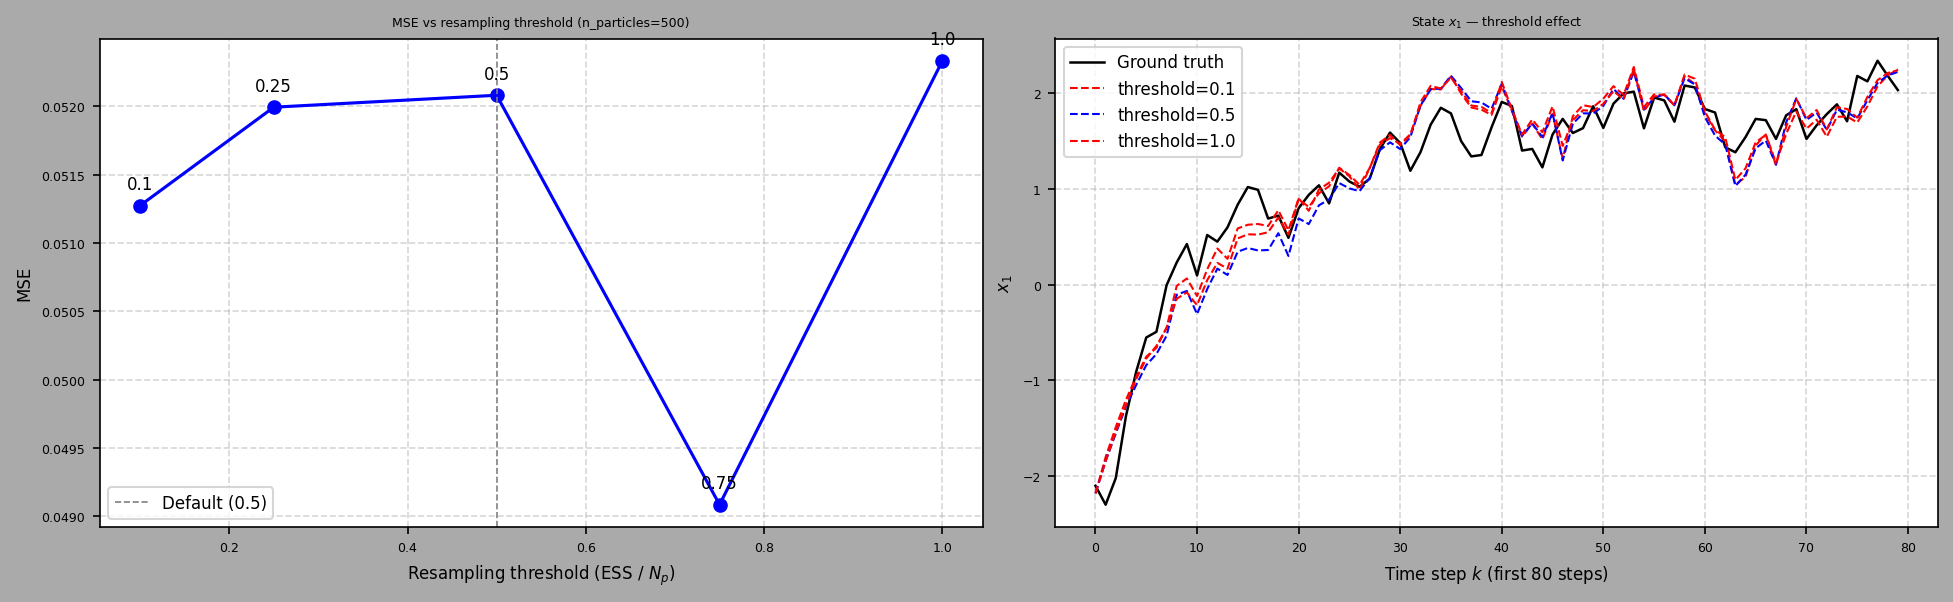

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: MSE vs threshold
ax = axes[0]
ths  = list(th_results.keys())
mses = [mse(*th_results[th]) for th in ths]
ax.plot(ths, mses, "o-", color="C5", lw=1.5)
for th, ms_ in zip(ths, mses):
    ax.annotate(f"{th}", (th, ms_), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
ax.axvline(0.5, color="grey", ls="--", lw=0.8, label="Default (0.5)")
ax.set_xlabel("Resampling threshold (ESS / $N_p$)")
ax.set_ylabel("MSE")
ax.set_title("MSE vs resampling threshold (n_particles=500)")
ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)

# Right: time series for extreme thresholds
ax = axes[1]
WIN = slice(0, 80)
xt_ref = th_results[0.5][0]
t = np.arange(len(xt_ref))
ax.plot(t[WIN], xt_ref[WIN, 0], color="black", lw=1.2, label="Ground truth")
for th, color in zip([0.1, 0.5, 1.0], ["C0", "C2", "C3"]):
    xu = th_results[th][1]
    ax.plot(t[WIN], xu[WIN, 0], lw=1.0, ls="--", color=color,
            label=f"threshold={th}")
ax.set_xlabel("Time step $k$ (first 80 steps)")
ax.set_ylabel("$x_1$")
ax.set_title("State $x_1$ — threshold effect")
ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
## 5. Filter Comparison on the Pairwise Model

We run all four filters on the **same simulated trajectory** from `model_x2_y1_pairwise`.  
The PPF exploits the pairwise structure; the PF ignores it but can still run on the same model.

In [21]:
# Simulate one trajectory on the pairwise model
ref_pw      = NonLinear_EPKF(param_pw, sKey=SEED)
sim_data_pw = ref_pw.simulate_N_data(N)
print(f"Simulated {len(sim_data_pw)} steps on {model_pw}")

Simulated 501 steps on Model_x2_y1_pairwise(dim_x=2, dim_y=1)


In [22]:
filters_pw = {
    "EPKF"          : NonLinear_EPKF(param_pw, sKey=SEED),
    "UPKF (wan2000)": NonLinear_UPKF(param_pw, sigmaSet="wan2000", sKey=SEED),
    "PPF (500)"     : NonLinear_PPF(param_pw, n_particles=500, sKey=SEED),
}
COLORS_PW = ["C0", "C1", "C2"]

print("Filter comparison — pairwise model (same trajectory):")
pw_results = {}
for name, flt in filters_pw.items():
    res = flt.process_N_data(N=None, data_generator=iter(sim_data_pw))
    xt, xu = extract(res)
    pw_results[name] = (xt, xu)
    print(f"  {name:<20s}   MSE = {mse(xt, xu):.6f}")

Filter comparison — pairwise model (same trajectory):
  EPKF                   MSE = 0.114498
  UPKF (wan2000)         MSE = 0.115211
  PPF (500)              MSE = 0.112804


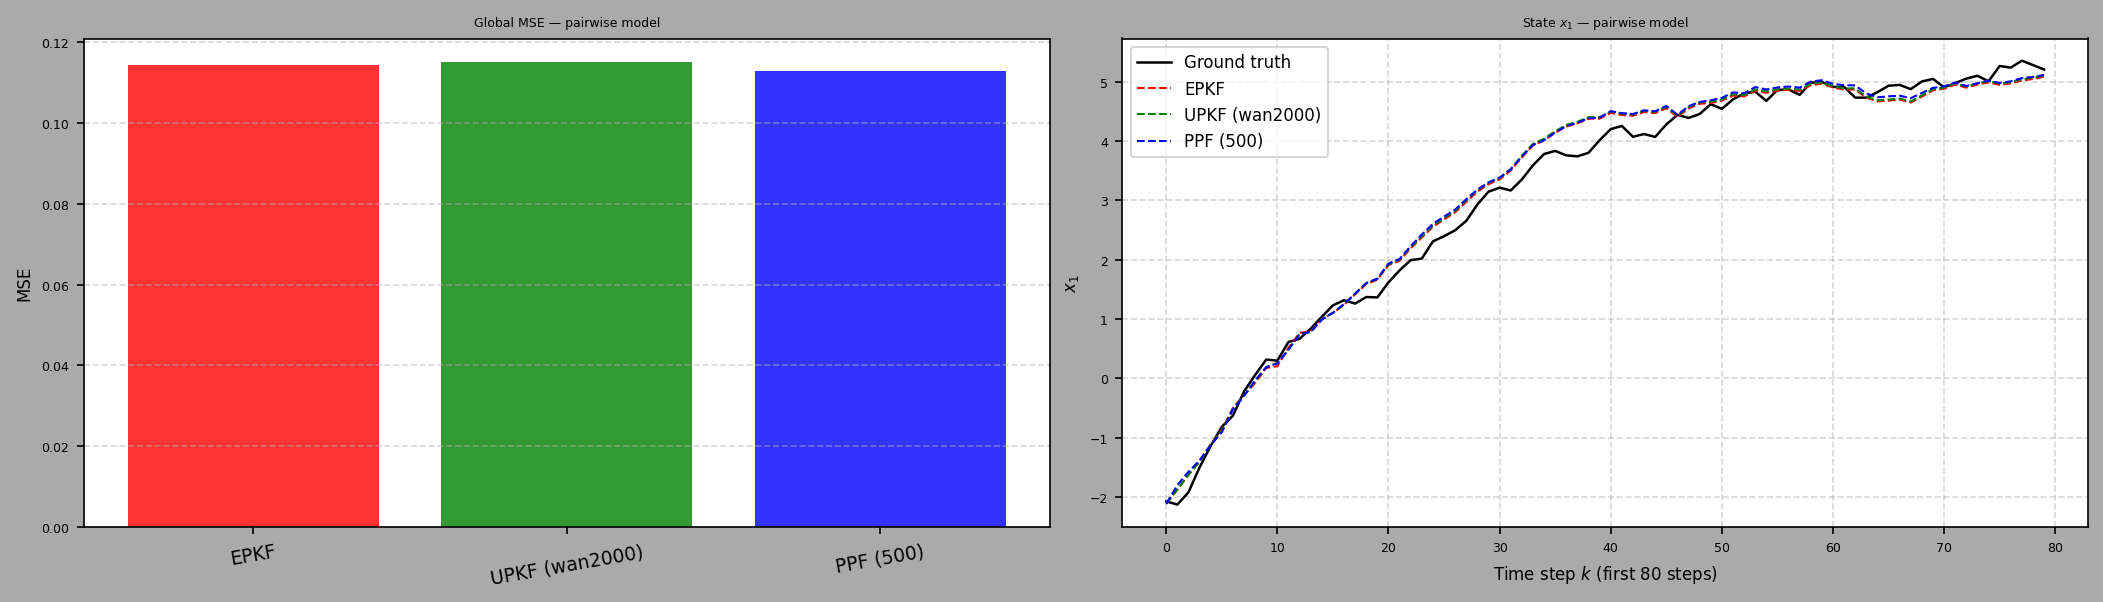

In [23]:
names  = list(pw_results.keys())
dim_x_pw = model_pw.get_params()["dim_x"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: global MSE bar chart
ax = axes[0]
mse_vals = [mse(*pw_results[n]) for n in names]
ax.bar(range(len(names)), mse_vals, color=COLORS_PW, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=10, fontsize=9)
ax.set_ylabel("MSE")
ax.set_title("Global MSE — pairwise model")
ax.grid(True, axis="y", ls="--", alpha=0.5)

# Right: state x1 time series — first 80 steps
ax = axes[1]
WIN = slice(0, 80)
xt_ref_pw = pw_results["EPKF"][0]
t_pw = np.arange(len(xt_ref_pw))
ax.plot(t_pw[WIN], xt_ref_pw[WIN, 0], color="black", lw=1.2, label="Ground truth")
for name, color in zip(names, COLORS_PW):
    xu = pw_results[name][1]
    ax.plot(t_pw[WIN], xu[WIN, 0], lw=1.0, ls="--", color=color, label=name)
ax.set_xlabel("Time step $k$ (first 80 steps)")
ax.set_ylabel("$x_1$")
ax.set_title("State $x_1$ — pairwise model")
ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
## 6. Per-Component MSE

For the 2D state, the filters may perform differently on each component $x_1$ and $x_2$.

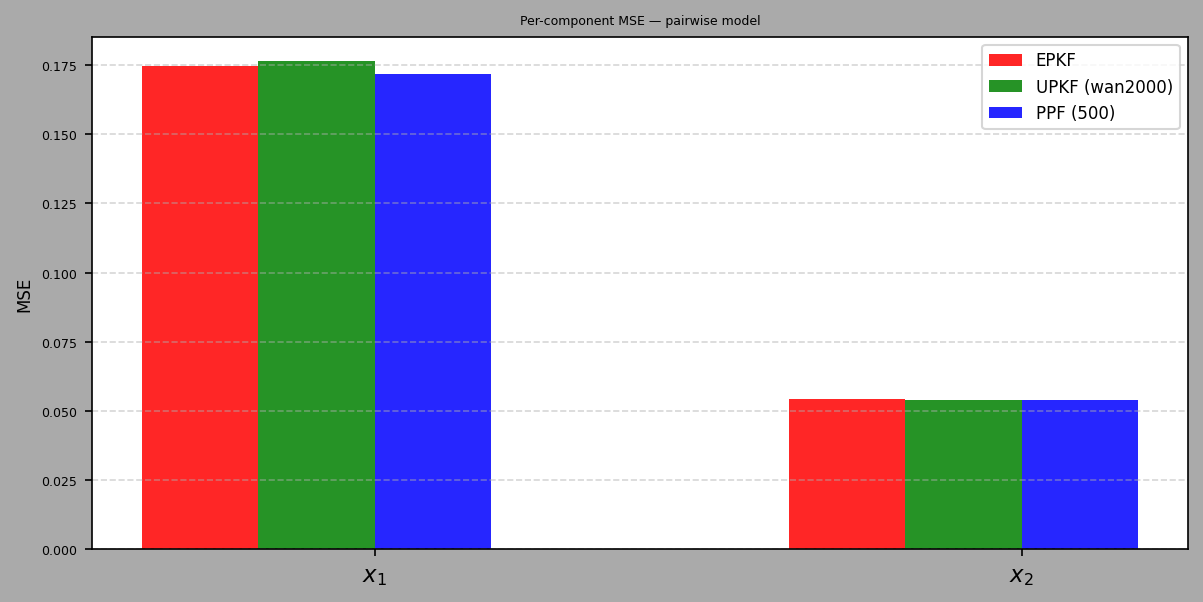

In [24]:
x_pos = np.arange(dim_x_pw)
w     = 0.18
labels_comp = [f"$x_{i+1}$" for i in range(dim_x_pw)]

fig, ax = plt.subplots(figsize=(8, 4))
for k, (name, color) in enumerate(zip(names, COLORS_PW)):
    xt, xu = pw_results[name]
    vals = [float(np.mean((xt[:, i] - xu[:, i]) ** 2)) for i in range(dim_x_pw)]
    ax.bar(x_pos + (k - 1.5) * w, vals, w, label=name, color=color, alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_comp, fontsize=11)
ax.set_ylabel("MSE")
ax.set_title("Per-component MSE — pairwise model")
ax.legend(fontsize=8)
ax.grid(True, axis="y", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 7. Computation Time Benchmark

We measure wall-clock time for PF (classic model) and PPF (pairwise model) across the same particle counts.

In [25]:
print(f"Benchmarking PF and PPF (N={N_BENCH}, {N_REPS} runs each)...")
bench_pf  = {}
bench_ppf = {}

for np_ in PARTICLE_COUNTS:
    # PF
    t_runs = []
    for _ in range(N_REPS):
        flt = NonLinear_PF(param_cl, n_particles=np_, sKey=SEED)
        t0  = time.perf_counter()
        flt.process_N_data(N=N_BENCH)
        t_runs.append(time.perf_counter() - t0)
    bench_pf[np_] = np.mean(t_runs)

    # PPF
    t_runs = []
    for _ in range(N_REPS):
        flt = NonLinear_PPF(param_pw, n_particles=np_, sKey=SEED)
        t0  = time.perf_counter()
        flt.process_N_data(N=N_BENCH)
        t_runs.append(time.perf_counter() - t0)
    bench_ppf[np_] = np.mean(t_runs)

    print(f"  n_particles={np_:5d}   PF: {bench_pf[np_]*1000:6.1f} ms   PPF: {bench_ppf[np_]*1000:6.1f} ms")

# EPKF reference
t_runs = []
for _ in range(N_REPS):
    flt = NonLinear_EPKF(param_cl, sKey=SEED)
    t0  = time.perf_counter()
    flt.process_N_data(N=N_BENCH)
    t_runs.append(time.perf_counter() - t0)
t_epkf_ms = np.mean(t_runs) * 1000
print(f"  {'EPKF (reference)':<22s}   {t_epkf_ms:6.1f} ms")

Benchmarking PF and PPF (N=500, 3 runs each)...
  n_particles=   50   PF:  268.0 ms   PPF:  273.7 ms
  n_particles=  100   PF:  375.8 ms   PPF:  413.7 ms
  n_particles=  200   PF:  593.6 ms   PPF:  714.6 ms
  n_particles=  500   PF: 1284.2 ms   PPF: 1543.6 ms
  n_particles= 1000   PF: 2431.1 ms   PPF: 2991.1 ms
  EPKF (reference)          129.3 ms


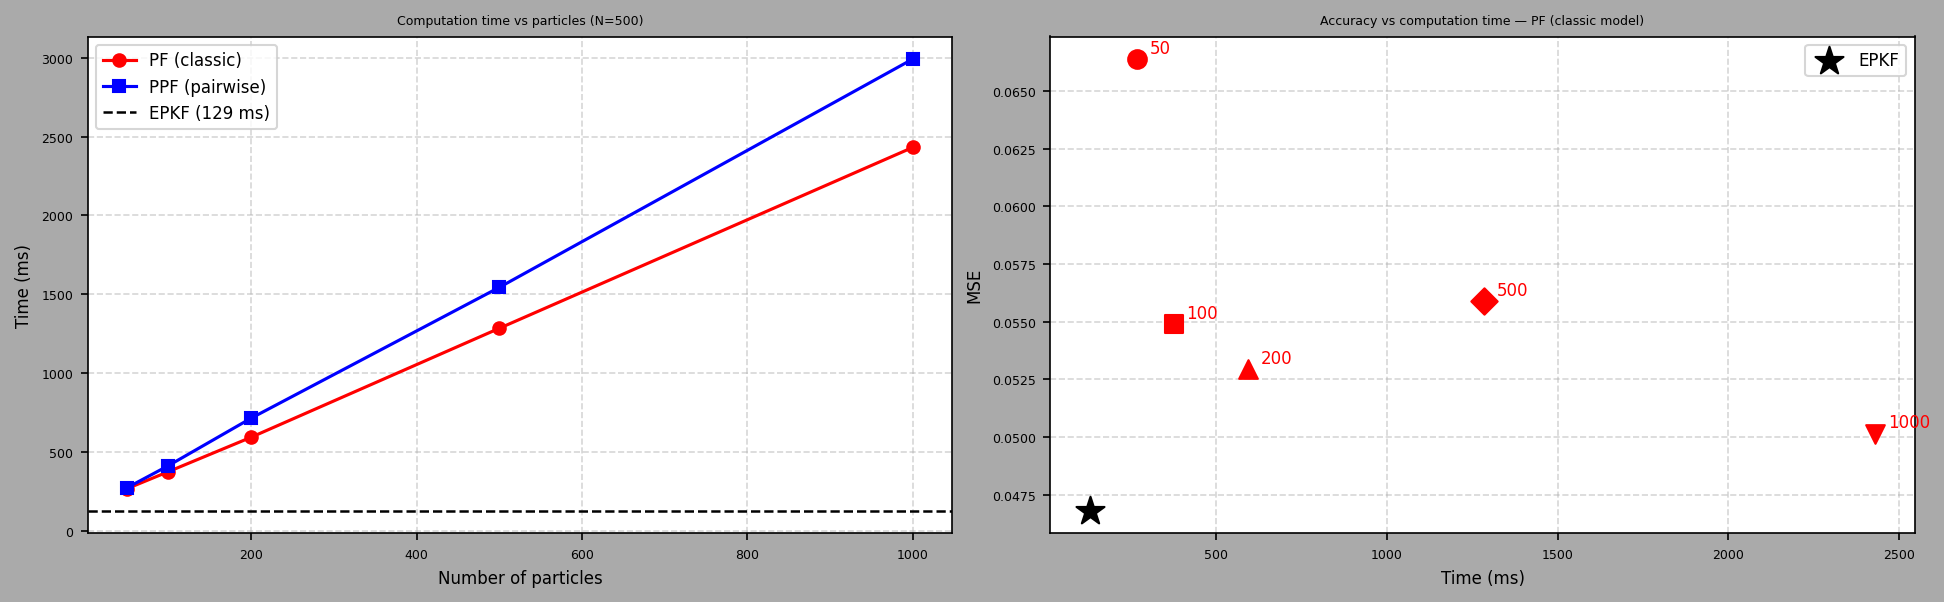

In [27]:
nps = PARTICLE_COUNTS

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: time vs N_particles
ax = axes[0]
ax.plot(nps, [bench_pf[n]  * 1000 for n in nps], "o-", color="C0", lw=1.5, label="PF (classic)")
ax.plot(nps, [bench_ppf[n] * 1000 for n in nps], "s-", color="C2", lw=1.5, label="PPF (pairwise)")
ax.axhline(t_epkf_ms, color="black", ls="--", lw=1.2, label=f"EPKF ({t_epkf_ms:.0f} ms)")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Time (ms)")
ax.set_title(f"Computation time vs particles (N={N_BENCH})")
ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)

# Right: MSE vs time (accuracy / cost trade-off for PF)
ax = axes[1]
for np_, marker in zip(nps, ["o", "s", "^", "D", "v"]):
    ax.scatter(bench_pf[np_] * 1000, pf_mse[np_],
               color="C0", marker=marker, s=80, zorder=4)
    ax.annotate(str(np_), (bench_pf[np_] * 1000, pf_mse[np_]),
                textcoords="offset points", xytext=(6, 3), fontsize=8, color="C0")

# EPKF MSE reference
res_e = NonLinear_EPKF(param_cl, sKey=SEED).process_N_data(N=N)
xt_e, xu_e = extract(res_e)
ax.scatter(t_epkf_ms, mse(xt_e, xu_e), color="black", marker="*",
           s=200, zorder=5, label="EPKF")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("MSE")
ax.set_title("Accuracy vs computation time — PF (classic model)")
ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
## 8. Practical Recommendations

| Scenario | Recommended choice | Reason |
|----------|--------------------|--------|
| Starting point | `NonLinear_PF(n_particles=500)` | Works on any model, robust |
| Pairwise model available | `NonLinear_PPF(n_particles=300)` | Improved proposal — fewer particles needed |
| Accuracy critical | Increase `n_particles` | MSE decreases as $O(1/N_p)$ |
| Speed critical | Reduce `n_particles` + use `stratified` | Best noise/time trade-off |
| Severe weight collapse | Increase `resample_threshold` (→ 0.75) | More frequent resampling |
| Particle impoverishment | Decrease `resample_threshold` (→ 0.25) | Less aggressive resampling |
| Comparison baseline | `NonLinear_EPKF` or `NonLinear_UPKF` | Deterministic, fast, no tuning |

**Rule of thumb:** start with `n_particles=500`, `resample_threshold=0.5`, `resample_method="stratified"` (all defaults). Increase particle count only if MSE is unsatisfactory — the accuracy gain above ~1000 particles is usually marginal.

---
## 9. Going Further

| Task | How |
|------|-----|
| Try a 1D nonlinear model | `ModelFactoryNonLinear.create("model_x1_y1_gordon_classic")` — the Gordon (1993) benchmark |
| Try a 2D observation pairwise model | `ModelFactoryNonLinear.create("model_x2_y2_pairwise")` |
| Run PPF with more particles | `NonLinear_PPF(param_pw, n_particles=2000)` |
| Use CLI | `awesomepkf-ppf --nonLinearModelName model_x2_y1_pairwise --nbParticles 500 --N 500 --plot` |
| Compare with UKF variants | `NonLinear_UKF` — standard (non-pairwise) unscented Kalman filter |

See `tutorial_03_sigma_points.ipynb` for a deep dive into sigma-point sets and UPKF calibration.